# Math 280: Mathematical and Statistical Foundations of Data Science
## Week 13 — Neighborhood and Topology: t-SNE and UMAP
### UC Merced | Spring 2026 | S. Sindi

---

This notebook accompanies the Week 13 Lecture 2 notes. The theme shifts from **reconstruction** (Lecture 1) to **neighborhood preservation**: instead of asking *can we recover $x$ from a compressed code?*, we ask *can we place nearby points near each other in 2D?*

The notebook is in three parts:

| Part | Dataset | What you will see |
|------|---------|-------------------|
| 1 | MNIST digits | The **good case** — t-SNE and UMAP at their best, compared to PCA |
| 2 | Swiss roll (synthetic) | The **bad case** — t-SNE creates clusters that do not exist |
| 3 | Swiss roll | **Perplexity dependence** — the same data, completely different pictures |

Part 2 and 3 are directly motivated by Chari & Pachter (2023), *The Specious Art of Single-Cell Genomics*, who use the Swiss roll to demonstrate that t-SNE and UMAP can produce topologically distorted embeddings that misrepresent the true structure of the data.

**Run every cell in order. Read the text between cells carefully — it explains what you are seeing and why it matters mathematically.**

---

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D

from sklearn.datasets import fetch_openml, make_swiss_roll
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# UMAP is a separate package — install with: pip install umap-learn
import umap

plt.rcParams.update({
    'figure.dpi': 110,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
})

SEED = 42
np.random.seed(SEED)

# Colour palette — one colour per MNIST digit class (0–9)
PALETTE = [
    '#4878D0', '#EE854A', '#6ACC65', '#D65F5F', '#B47CC7',
    '#C4AD66', '#77BEDB', '#F7B4C1', '#A8786E', '#8C8C8C'
]

print('Ready.')

/Users/suzanne/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Ready.


---
## Part 1 — The Good Case: MNIST Digits

### The Dataset

MNIST is a dataset of 70,000 handwritten digit images (0–9), each 28×28 pixels = 784 dimensions. It is the standard benchmark for dimensionality reduction visualisation because:

- The true structure is known: there are 10 classes (digits), so we can colour points by label and immediately see whether a method found the right clusters.
- 784 dimensions is high enough that PCA struggles but t-SNE and UMAP shine.
- The dataset is large enough for neighbourhood methods to work well.

We work with a random subset of **8,000 images** — enough to see clear structure, small enough to run t-SNE in a reasonable time.

**Important**: we use the labels *only for colouring the plot*, never for fitting the methods. PCA, t-SNE, and UMAP are all fully unsupervised — they never see the digit labels.

Loading MNIST (this may take a moment on first run)...
Full dataset : 70000 images, 784 pixels each
Working subset: 8000 images (800 per digit)


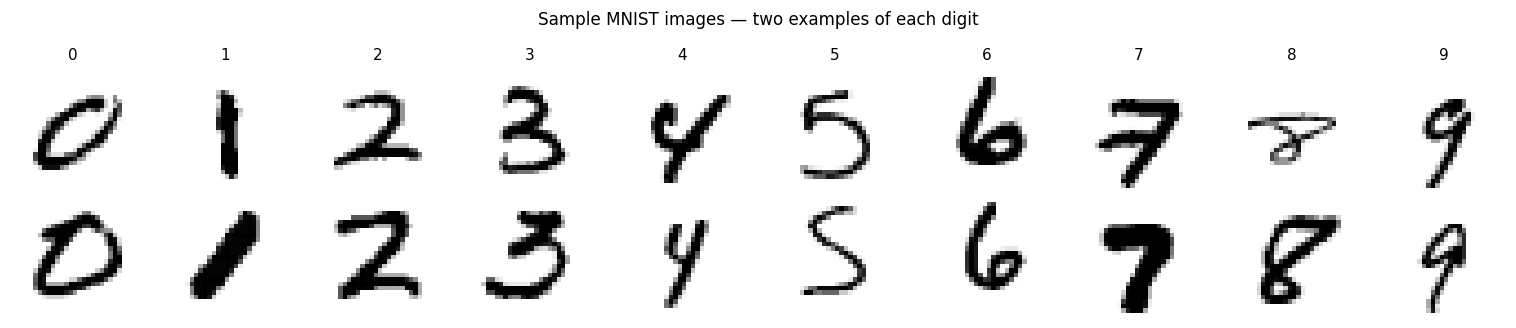

In [2]:
# ── Load MNIST ────────────────────────────────────────────────────────────────
# fetch_openml downloads and caches the data automatically
print('Loading MNIST (this may take a moment on first run)...')
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X_full = mnist.data.astype(float) / 255.0   # scale pixels to [0, 1]
y_full = mnist.target.astype(int)

print(f'Full dataset : {X_full.shape[0]} images, {X_full.shape[1]} pixels each')

# ── Subsample 8000 images, stratified by digit ────────────────────────────────
# We take 800 images per digit so all 10 classes are equally represented
N_PER_CLASS = 800
idx = []
for digit in range(10):
    digit_idx = np.where(y_full == digit)[0]
    chosen    = np.random.choice(digit_idx, N_PER_CLASS, replace=False)
    idx.extend(chosen)
idx = np.array(idx)
np.random.shuffle(idx)

X = X_full[idx]
y = y_full[idx]

print(f'Working subset: {X.shape[0]} images ({N_PER_CLASS} per digit)')

# ── Show a sample of digits ───────────────────────────────────────────────────
fig, axes = plt.subplots(2, 10, figsize=(14, 3))
for digit in range(10):
    examples = np.where(y == digit)[0][:2]
    for row, idx_ex in enumerate(examples):
        axes[row, digit].imshow(X[idx_ex].reshape(28, 28), cmap='gray_r')
        axes[row, digit].axis('off')
        if row == 0:
            axes[row, digit].set_title(str(digit), fontsize=10)
fig.suptitle('Sample MNIST images — two examples of each digit', fontsize=11)
plt.tight_layout()
plt.show()

In [6]:
pip install --upgrade umap-learn scikit-learn

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### Step 1: PCA Pre-processing

A critical practical point from the lecture notes: **t-SNE and UMAP are never applied directly to raw high-dimensional data in practice**. Instead, we first reduce to 50 PCA components. This:

1. Removes noise (the bottom principal components capture noise, not signal)
2. Dramatically speeds up t-SNE (computing pairwise distances in $\mathbb{R}^{50}$ is much faster than in $\mathbb{R}^{784}$)
3. Makes the Gaussian kernel in t-SNE more meaningful

This is the standard pipeline: raw data $\to$ PCA (50 components) $\to$ t-SNE or UMAP (2 components).

In [3]:
# ── Step 1: reduce to 50 PCA components ──────────────────────────────────────
# This is preprocessing for t-SNE/UMAP, not the final visualisation
N_PCA = 50
pca_pre = PCA(n_components=N_PCA, random_state=SEED)
X_pca50 = pca_pre.fit_transform(X)

var_explained = pca_pre.explained_variance_ratio_.sum()
print(f'{N_PCA} PCA components explain {var_explained:.1%} of total variance')
print(f'Reduced from {X.shape[1]} to {X_pca50.shape[1]} dimensions for t-SNE/UMAP input')

# ── Also keep 2D PCA for comparison plots ────────────────────────────────────
pca_2d = PCA(n_components=2, random_state=SEED)
X_pca2 = pca_2d.fit_transform(X)
print(f'\n2D PCA explains {pca_2d.explained_variance_ratio_.sum():.1%} of variance')
print('(This is what we will plot alongside t-SNE and UMAP for comparison)')

50 PCA components explain 82.7% of total variance
Reduced from 784 to 50 dimensions for t-SNE/UMAP input

2D PCA explains 16.7% of variance
(This is what we will plot alongside t-SNE and UMAP for comparison)


### Step 2: t-SNE

Recall from the lecture notes that t-SNE minimises the KL divergence between high-dimensional affinities $p_{ij}$ (Gaussian kernel) and low-dimensional affinities $q_{ij}$ (Student-$t$ kernel):

$$\mathcal{L} = \mathrm{KL}(P \| Q) = \sum_{i \neq j} p_{ij} \log \frac{p_{ij}}{q_{ij}}$$

The key hyperparameter is **perplexity** — a smooth measure of the effective number of neighbours around each point. We use the commonly recommended value of 30 here, and explore its effect in Part 3.

t-SNE is slow — expect this cell to take 1–3 minutes.

In [4]:
# ── Fit t-SNE on the 50-dimensional PCA representation ───────────────────────
# init='pca' initialises the embedding with PCA coordinates — this is strongly
# recommended by Kobak & Berens (2019) for reproducibility and faster convergence
print('Fitting t-SNE (perplexity=30, PCA init)...')
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate='auto',
    init='pca',           # PCA initialisation — more reproducible than random
    random_state=SEED,
    n_iter=1000,
)
X_tsne = tsne.fit_transform(X_pca50)
print(f'Done. Embedding shape: {X_tsne.shape}')

Fitting t-SNE (perplexity=30, PCA init)...


/Users/suzanne/Library/Python/3.9/lib/python/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Done. Embedding shape: (8000, 2)


### Step 3: UMAP

UMAP builds a fuzzy $k$-nearest-neighbour graph in the high-dimensional space and then finds a 2D embedding that best matches it via a cross-entropy objective. The key hyperparameter is `n_neighbors` — analogous to perplexity in t-SNE.

UMAP is substantially faster than t-SNE and generally preserves more global structure.

In [5]:
# ── Fit UMAP on the 50-dimensional PCA representation ────────────────────────
print('Fitting UMAP (n_neighbors=15)...')

# Cast to float32 explicitly — fixes compatibility with older umap-learn versions
X_pca50_f32 = X_pca50.astype(np.float32)

reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    random_state=SEED,
)
X_umap = reducer.fit_transform(X_pca50_f32)
print(f'Done. Embedding shape: {X_umap.shape}')

Fitting UMAP (n_neighbors=15)...


/Users/suzanne/Library/Python/3.9/lib/python/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Done. Embedding shape: (8000, 2)


### The Comparison: PCA vs t-SNE vs UMAP

Now we plot all three embeddings side by side, coloured by digit label. Remember: the methods never saw these labels — we are using them only to evaluate whether the unsupervised structure matches the known ground truth.

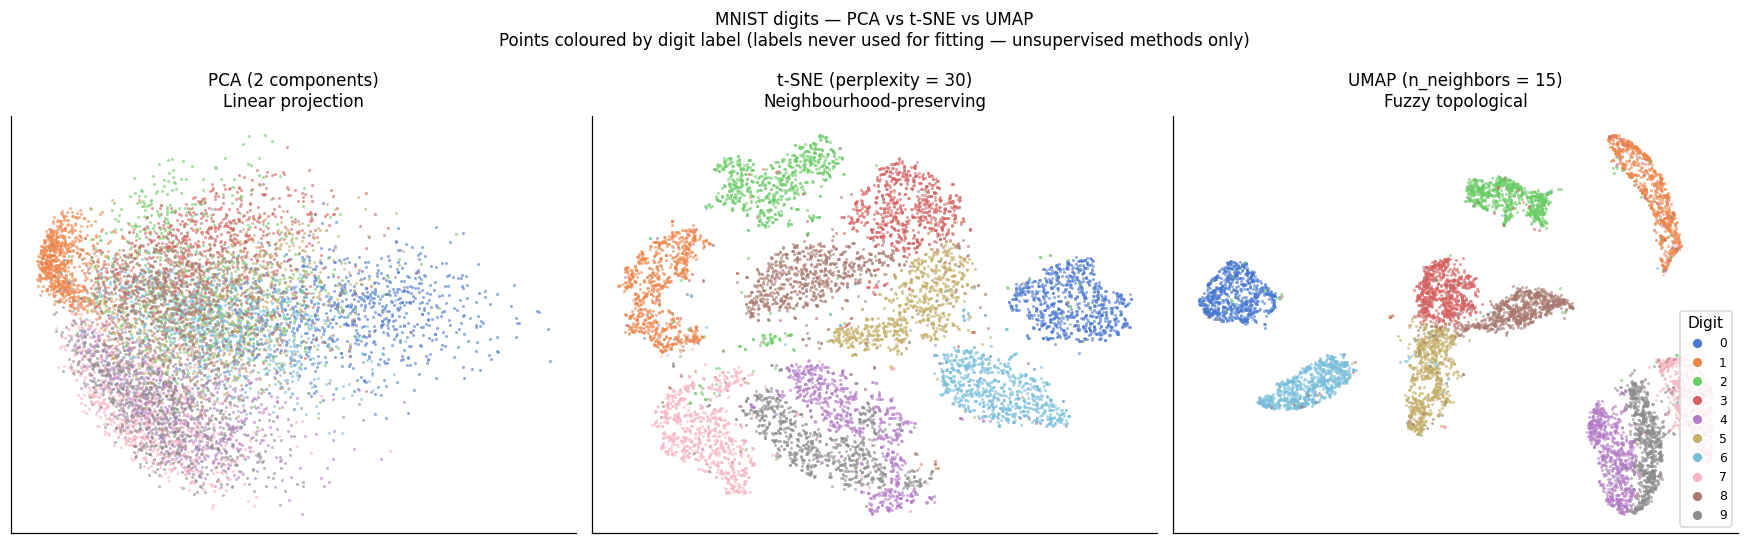

In [7]:
def scatter_embedding(ax, Z, labels, title, legend=False):
    """
    Scatter plot of a 2D embedding Z, coloured by integer labels.
    Uses a fixed colour palette so digit colours are consistent across panels.
    """
    for digit in range(10):
        mask = labels == digit
        ax.scatter(
            Z[mask, 0], Z[mask, 1],
            c=PALETTE[digit], s=4, alpha=0.6, linewidths=0,
            label=str(digit)
        )
    ax.set_title(title, fontsize=11)
    ax.set_xticks([])
    ax.set_yticks([])
    if legend:
        handles = [Line2D([0], [0], marker='o', color='w',
                          markerfacecolor=PALETTE[d], markersize=7, label=str(d))
                   for d in range(10)]
        ax.legend(handles=handles, title='Digit', fontsize=8,
                  loc='lower right', framealpha=0.8)


fig, axes = plt.subplots(1, 3, figsize=(16, 5))

scatter_embedding(axes[0], X_pca2,  y, 'PCA (2 components)\nLinear projection')
scatter_embedding(axes[1], X_tsne,  y, 't-SNE (perplexity = 30)\nNeighbourhood-preserving')
scatter_embedding(axes[2], X_umap,  y, 'UMAP (n_neighbors = 15)\nFuzzy topological', legend=True)

fig.suptitle(
    'MNIST digits — PCA vs t-SNE vs UMAP\n'
    'Points coloured by digit label (labels never used for fitting — unsupervised methods only)',
    fontsize=11
)
plt.tight_layout()
plt.show()

### What Are We Seeing?

**PCA** projects onto the two directions of maximum variance. The digit classes are somewhat separated — PCA is detecting that digits differ — but the clusters heavily overlap. This is because PCA is linear: it cannot capture the curved, nonlinear boundaries between digit classes in pixel space.

**t-SNE** produces beautifully separated clusters. Each digit forms a tight island, and visually similar digits (e.g., 4 and 9, or 3 and 8) are placed near each other. This is t-SNE doing exactly what it is designed to do — preserving local neighbourhood structure.

**UMAP** produces similar cluster separation to t-SNE but with more meaningful inter-cluster distances. Related digits are still near each other, but the global arrangement of clusters is more faithful to the true high-dimensional structure.

**Critical warning**: the fact that t-SNE produces beautiful clusters on MNIST does not mean it always will. MNIST is a best case — the classes are genuinely well-separated in high dimensions. In Part 2 we see what happens when the true structure is continuous, not discrete.

---
## Part 2 — The Bad Case: The Swiss Roll

### Motivation

The Swiss roll is the synthetic example used by Chari & Pachter (2023) to demonstrate that t-SNE and UMAP can produce **topologically distorted embeddings** — they create discrete clusters in data that has no cluster structure whatsoever.

The true structure is a **2D sheet rolled up into 3D** — like a cinnamon roll or a rolled-up piece of paper. Points that are far apart in 3D Euclidean distance may be close together on the surface of the sheet. A faithful embedding should unroll the sheet back into a flat rectangle; the colour gradient should be smooth.

The variable `t` returned by `make_swiss_roll` is the position along the roll — the ground truth continuous coordinate. We colour by `t`.

Swiss roll shape : (3000, 3)  (3D coordinates)
t range          : [4.71, 14.13]  (position along roll)


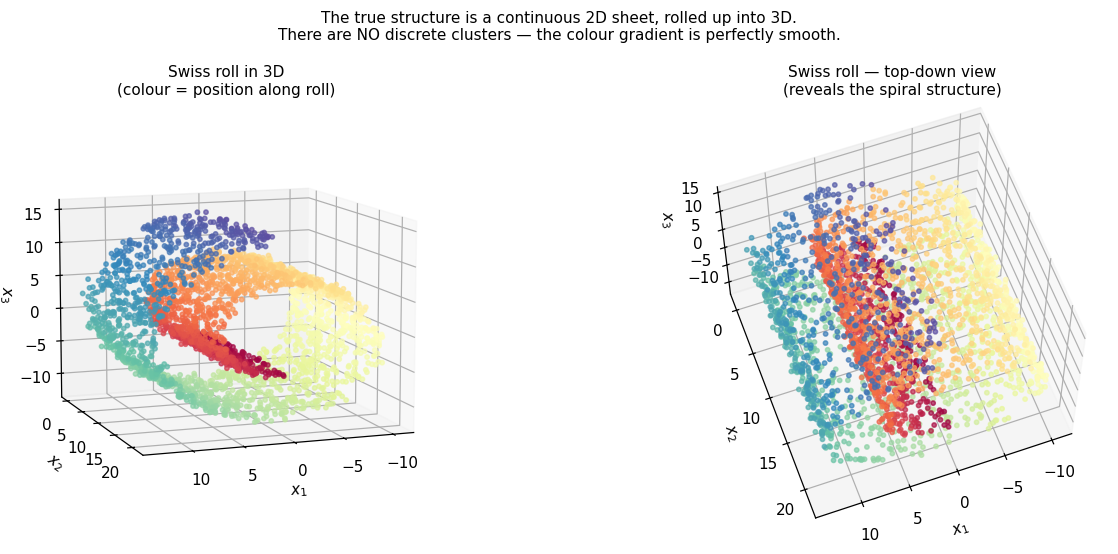

In [8]:
# ── Generate the Swiss roll ───────────────────────────────────────────────────
# n_samples: number of points on the roll
# noise: small Gaussian noise added to the 3D coordinates
# t: the position along the roll — the ground truth continuous variable
N_ROLL = 3000
X_roll, t_roll = make_swiss_roll(n_samples=N_ROLL, noise=0.3, random_state=SEED)

print(f'Swiss roll shape : {X_roll.shape}  (3D coordinates)')
print(f't range          : [{t_roll.min():.2f}, {t_roll.max():.2f}]  (position along roll)')

# ── Visualise the Swiss roll in 3D ────────────────────────────────────────────
fig = plt.figure(figsize=(13, 5))

# View 1: front
ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(X_roll[:, 0], X_roll[:, 1], X_roll[:, 2],
            c=t_roll, cmap='Spectral', s=8, alpha=0.7)
ax1.set_title('Swiss roll in 3D\n(colour = position along roll)', fontsize=10)
ax1.set_xlabel('$x_1$'); ax1.set_ylabel('$x_2$'); ax1.set_zlabel('$x_3$')
ax1.view_init(elev=10, azim=70)

# View 2: top-down — reveals the spiral
ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(X_roll[:, 0], X_roll[:, 1], X_roll[:, 2],
            c=t_roll, cmap='Spectral', s=8, alpha=0.7)
ax2.set_title('Swiss roll — top-down view\n(reveals the spiral structure)', fontsize=10)
ax2.set_xlabel('$x_1$'); ax2.set_ylabel('$x_2$'); ax2.set_zlabel('$x_3$')
ax2.view_init(elev=60, azim=70)

plt.suptitle(
    'The true structure is a continuous 2D sheet, rolled up into 3D.\n'
    'There are NO discrete clusters — the colour gradient is perfectly smooth.',
    fontsize=10
)
plt.tight_layout()
plt.show()

### Applying PCA, t-SNE, and UMAP to the Swiss Roll

A **faithful** 2D embedding of the Swiss roll should:
- Show a smooth colour gradient — no abrupt boundaries
- Show no discrete clusters — there are none in the true data
- Unroll the sheet so that points close on the surface are close in 2D

Watch carefully what each method does instead.

In [9]:
# ── PCA on the Swiss roll ─────────────────────────────────────────────────────
# PCA finds the two directions of maximum variance in 3D
# It projects the roll onto a flat plane — it cannot unroll the spiral
pca_roll = PCA(n_components=2, random_state=SEED)
X_roll_pca = pca_roll.fit_transform(X_roll)
print(f'PCA variance explained: {pca_roll.explained_variance_ratio_.sum():.1%}')

# ── t-SNE on the Swiss roll ───────────────────────────────────────────────────
# We use the default perplexity=30 — we will vary this in Part 3
print('Fitting t-SNE on Swiss roll...')
tsne_roll = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate='auto',
    init='pca',
    random_state=SEED,
    n_iter=1000,
)
X_roll_tsne = tsne_roll.fit_transform(X_roll)
print('Done.')

# ── UMAP on the Swiss roll ────────────────────────────────────────────────────
print('Fitting UMAP on Swiss roll...')
reducer_roll = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    random_state=SEED,
)
X_roll_umap = reducer_roll.fit_transform(X_roll)
print('Done.')

PCA variance explained: 71.8%
Fitting t-SNE on Swiss roll...


/Users/suzanne/Library/Python/3.9/lib/python/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Done.
Fitting UMAP on Swiss roll...


/Users/suzanne/Library/Python/3.9/lib/python/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Done.


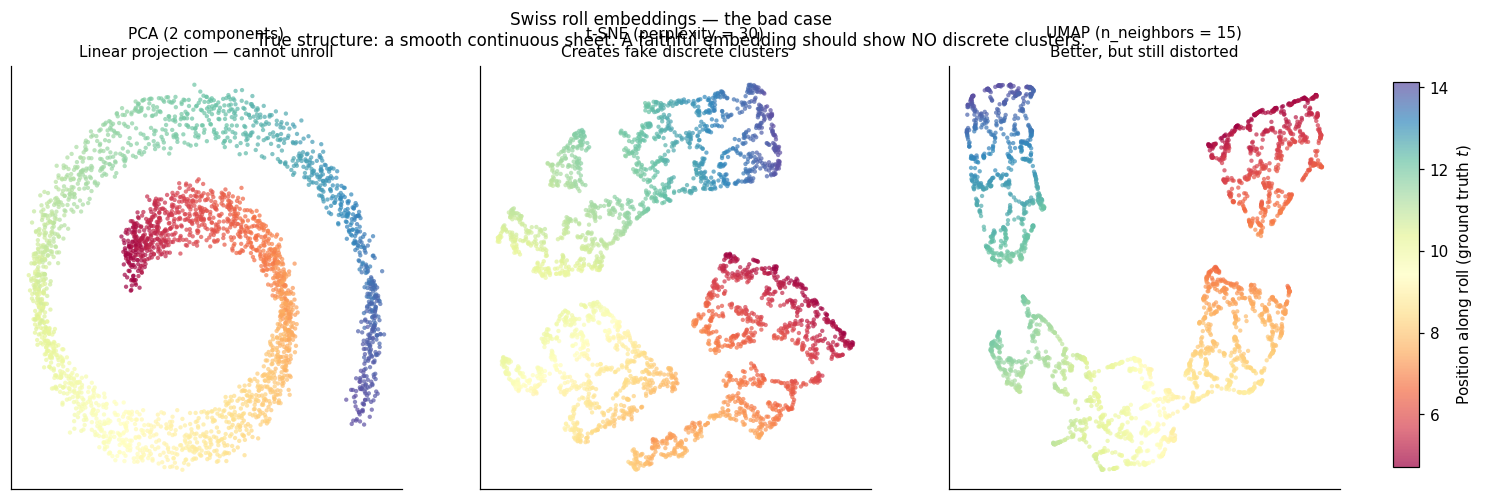

In [10]:
# ── Plot all three embeddings of the Swiss roll ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

titles = [
    'PCA (2 components)\nLinear projection — cannot unroll',
    't-SNE (perplexity = 30)\nCreates fake discrete clusters',
    'UMAP (n_neighbors = 15)\nBetter, but still distorted',
]
embeddings = [X_roll_pca, X_roll_tsne, X_roll_umap]

for ax, Z, title in zip(axes, embeddings, titles):
    sc = ax.scatter(Z[:, 0], Z[:, 1], c=t_roll, cmap='Spectral',
                    s=8, alpha=0.7, linewidths=0)
    ax.set_title(title, fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])

# Shared colourbar — shows the ground truth position along the roll
fig.subplots_adjust(right=0.88)
cbar_ax = fig.add_axes([0.91, 0.15, 0.015, 0.7])
fig.colorbar(sc, cax=cbar_ax, label='Position along roll (ground truth $t$)')

fig.suptitle(
    'Swiss roll embeddings — the bad case\n'
    'True structure: a smooth continuous sheet. A faithful embedding should show NO discrete clusters.',
    fontsize=11
)
plt.show()

### What Went Wrong?

**PCA** projects the 3D roll onto a flat plane. The result is a smeared ellipse — the spiral structure is visible but overlapping layers of the roll are projected on top of each other. PCA cannot unroll the manifold because unrolling requires a nonlinear map.

**t-SNE** produces what appear to be several discrete clusters separated by empty space. But look at the colour gradient — the boundaries between "clusters" cut straight through what should be a smooth transition. **These clusters do not exist in the data.** t-SNE has torn the continuous sheet into islands. This is the cluster exaggeration failure mode proven theoretically in arXiv:2510.07746.

**UMAP** does better — it partially unrolls the sheet and the gradient is smoother. But depending on `n_neighbors`, it can also produce artificial islands. Try changing `n_neighbors` to 5 or 100 in the cell above and re-running.

The key lesson: **a beautiful 2D plot is not evidence of real cluster structure.** The Swiss roll has no clusters, yet t-SNE confidently draws them.

---
## Part 3 — Perplexity Dependence: The Same Data, Different Pictures

The **perplexity** parameter in t-SNE controls the effective number of neighbours considered around each point. It is arguably the most important hyperparameter, and the same dataset can look completely different at different perplexity values.

Wattenberg, Viégas & Johnson (2016) — *How to Use t-SNE Effectively* — demonstrated empirically that varying perplexity can change the number of apparent clusters, their shapes, and their relative positions. We reproduce a version of that demonstration here.

We run t-SNE on the Swiss roll at six perplexity values: 2, 5, 15, 30, 50, and 100.

In [ ]:
# ── t-SNE at multiple perplexity values ───────────────────────────────────────
# Warning: this fits 6 separate t-SNE models — may take several minutes
perplexities = [2, 5, 15, 30, 50, 100]
roll_tsne_results = {}

for perp in perplexities:
    print(f'Fitting t-SNE with perplexity = {perp}...')
    tsne_p = TSNE(
        n_components=2,
        perplexity=perp,
        learning_rate='auto',
        init='pca',
        random_state=SEED,
        n_iter=1000,
    )
    roll_tsne_results[perp] = tsne_p.fit_transform(X_roll)

print('All done.')

Fitting t-SNE with perplexity = 2...


/Users/suzanne/Library/Python/3.9/lib/python/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Fitting t-SNE with perplexity = 5...


/Users/suzanne/Library/Python/3.9/lib/python/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Fitting t-SNE with perplexity = 15...


/Users/suzanne/Library/Python/3.9/lib/python/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Fitting t-SNE with perplexity = 30...


/Users/suzanne/Library/Python/3.9/lib/python/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


In [ ]:
# ── Plot t-SNE at all perplexity values ───────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax, perp in zip(axes, perplexities):
    Z = roll_tsne_results[perp]
    sc = ax.scatter(Z[:, 0], Z[:, 1], c=t_roll, cmap='Spectral',
                    s=8, alpha=0.7, linewidths=0)
    ax.set_title(f'Perplexity = {perp}', fontsize=11)
    ax.set_xticks([])
    ax.set_yticks([])

fig.subplots_adjust(right=0.88)
cbar_ax = fig.add_axes([0.91, 0.15, 0.015, 0.7])
fig.colorbar(sc, cax=cbar_ax, label='Position along roll (ground truth $t$)')

fig.suptitle(
    't-SNE on the Swiss roll at six perplexity values\n'
    'The true structure (a continuous sheet) is identical in every panel.\n'
    'The apparent cluster structure changes dramatically with perplexity.',
    fontsize=11
)
plt.show()

### What Are We Seeing?

Every panel shows **exactly the same 3,000 data points**. The only thing that changes is the perplexity parameter.

- **Low perplexity (2, 5)**: t-SNE only considers very local neighbourhoods. Points clump into many tiny islands — the global structure is completely lost. The colour gradient is broken into fragments.

- **Medium perplexity (15, 30)**: the classic t-SNE regime. A small number of apparent clusters emerge. The colour gradient within each "cluster" is locally smooth, but the boundaries between clusters are artificial tears in the continuous sheet.

- **High perplexity (50, 100)**: t-SNE considers larger neighbourhoods and the embedding becomes more global. The result starts to look more like PCA — the spiral structure is partially visible, but now individual clusters merge together.

**The critical point**: if you did not know the ground truth (the Swiss roll structure), you would look at the medium-perplexity plots and confidently conclude the data has 3–5 discrete clusters. It does not. This is exactly the failure mode Chari & Pachter (2023) documented in published single-cell genomics papers.

---
## Part 4 — UMAP Perplexity Dependence

UMAP has an analogous hyperparameter: `n_neighbors`. We repeat the same exercise to show that UMAP is also sensitive to this choice, though it tends to be more stable than t-SNE and better at preserving global structure at higher values.

In [ ]:
# ── UMAP at multiple n_neighbors values ───────────────────────────────────────
n_neighbors_values = [2, 5, 15, 30, 50, 100]
roll_umap_results  = {}

for nn in n_neighbors_values:
    print(f'Fitting UMAP with n_neighbors = {nn}...')
    reducer_nn = umap.UMAP(
        n_components=2,
        n_neighbors=nn,
        min_dist=0.1,
        random_state=SEED,
    )
    roll_umap_results[nn] = reducer_nn.fit_transform(X_roll)

print('All done.')

In [ ]:
# ── Plot UMAP at all n_neighbors values ───────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax, nn in zip(axes, n_neighbors_values):
    Z = roll_umap_results[nn]
    sc = ax.scatter(Z[:, 0], Z[:, 1], c=t_roll, cmap='Spectral',
                    s=8, alpha=0.7, linewidths=0)
    ax.set_title(f'n_neighbors = {nn}', fontsize=11)
    ax.set_xticks([])
    ax.set_yticks([])

fig.subplots_adjust(right=0.88)
cbar_ax = fig.add_axes([0.91, 0.15, 0.015, 0.7])
fig.colorbar(sc, cax=cbar_ax, label='Position along roll (ground truth $t$)')

fig.suptitle(
    'UMAP on the Swiss roll at six n_neighbors values\n'
    'Compare to the t-SNE panels — UMAP is more stable at higher n_neighbors\n'
    'but still distorts the true continuous structure at low values.',
    fontsize=11
)
plt.show()

---
## Summary

| | PCA | t-SNE | UMAP |
|---|---|---|---|
| **Objective** | Maximise variance (= minimise reconstruction error) | Minimise KL divergence between neighbourhood distributions | Minimise cross-entropy between fuzzy $k$-NN graphs |
| **What it preserves** | Global linear structure | Local neighbourhoods | Local + some global structure |
| **What it distorts** | Nonlinear/curved structure | Inter-cluster distances, cluster sizes | Less than t-SNE, but still distorts |
| **Key hyperparameter** | $k$ (number of components) | Perplexity | `n_neighbors` |
| **Speed** | Fast (SVD) | Slow $O(n^2)$ | Fast $O(n^{1.14})$ |
| **Can create fake clusters?** | No | **Yes — proven** | Yes, at low `n_neighbors` |
| **Good for** | Analysis, compression | Visualisation of well-separated clusters | Visualisation with better global structure |

### The take-away from the Swiss roll

The Swiss roll has **no discrete clusters**. Yet t-SNE confidently draws them, and the picture changes completely with perplexity. This is not a pathological edge case — it is the expected behaviour of the algorithm, now proven theoretically (arXiv:2510.07746).

The appropriate stance is:
- Use t-SNE and UMAP for **hypothesis generation and communication**, not confirmation
- Always vary the hyperparameter and check whether your conclusions change
- Never use inter-cluster distances to draw biological or scientific conclusions
- Treat the plot as one piece of evidence, not as the result itself

---
## Reflection Questions

Write your answers in new markdown cells below each question.

---

**Q1.** Look at the MNIST comparison (Part 1). t-SNE produces beautifully separated clusters; PCA does not. Does this mean t-SNE found something real that PCA missed, or could the t-SNE clusters also be artificial? How would you decide?

---

**Q2.** In Part 3, the t-SNE plot at perplexity = 2 and perplexity = 100 look completely different. If you were a biologist looking at single-cell RNA-seq data and you saw one of these plots, what would you conclude about the number of cell types? What does this tell you about the scientific status of a t-SNE plot?

---

**Q3.** The Swiss roll is a 2D manifold embedded in 3D. UMAP at large `n_neighbors` does a much better job of unrolling it than t-SNE does. Based on what you know about the mathematical objectives of the two methods, why might UMAP handle global structure better than t-SNE?

---

*Math 280 | UC Merced | Spring 2026 | S. Sindi*